In [23]:
# Repair Cell: Run this, then RESTART SESSION
!pip install -U huggingface_hub transformers accelerate --quiet
print("✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.")

✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.


In [2]:
#--------------------------------------------------------------------------------------------------------
# MODULE 0: Environment Update
#--------------------------------------------------------------------------------------------------------

!pip install -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 75.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.1 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.3
    Uninstalling datasets-4.8.3:
      Successfully uninstalled datasets-4.8.3
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0


In [3]:
#-------------------------------------------------------------------------
# MODULE 0: Library Version Fix
#-------------------------------------------------------------------------
!pip uninstall -y transformers huggingface_hub
!pip install transformers==4.48.0 huggingface_hub==0.27.0 --quiet

print("✅ Libraries downgraded to stable versions. PLEASE RESTART SESSION NOW.")

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.4.1
Uninstalling huggingface_hub-1.4.1:
  Successfully uninstalled huggingface_hub-1.4.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 73.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.5/450.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.27.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.27.0 which is incompatible.
✅ Li

In [1]:
from kaggle_secrets import UserSecretsClient
hf_token = UserSecretsClient().get_secret("HF_TOKEN")

In [2]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1: Standard Environment Setup
#--------------------------------------------------------------------------------------------------------
import os
import sys

# 1. Standard PyTorch Import (Let this finish first)
import torch
import torch.nn as nn
import torch.nn.functional as F

# 2. Data & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# 3. Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from torch.optim import AdamW 

# 4. Transformers (The Ensemble Backbones)
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# 5. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Environment Reset Successful.")
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ Running on: {device}")

✅ Environment Reset Successful.
✅ PyTorch Version: 2.10.0+cu128
✅ Running on: cuda


In [3]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1.5: Verification Script
#--------------------------------------------------------------------------------------------------------

from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    token = user_secrets.get_secret("HF_TOKEN")
    
    print("Testing connection to gated dataset...")
    # Loading just a tiny sliver to verify access
    test_load = load_dataset("AIMH/SWMH", token=token, split='train', streaming=True)
    print("🚀 Success! Dataset is reachable and token is valid.")
    
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Ensure you have accepted the terms at: https://huggingface.co/datasets/AIMH/SWMH")

Testing connection to gated dataset...


README.md: 0.00B [00:00, ?B/s]

🚀 Success! Dataset is reachable and token is valid.


In [4]:
#--------------------------------------------------------------------------------------------------------
# MODULE 2: The "Double Agent" Configuration
#--------------------------------------------------------------------------------------------------------

class Config:
    BERT_NAME    = 'mental/mental-bert-base-uncased'
    ROBERTA_NAME = 'roberta-base'          # ✅ Full RoBERTa, not distilled
    
    MAX_LEN    = 256
    BATCH_SIZE = 16
    EPOCHS     = 6                         # ✅ More epochs
    LR_TRANSFORMER = 2e-5
    LR_WEIGHTS     = 1e-3
    WARMUP_RATIO   = 0.1                   # ✅ 10% of steps for warmup
    RANDOM_SEED    = 42

config = Config()

In [5]:
#--------------------------------------------------------------------------------------------------------
# MODULE 3: Data Pipeline (Zero-Leakage Edition)
#--------------------------------------------------------------------------------------------------------

def load_and_preprocess_data():
    base_path = "/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/"
    df = pd.read_csv(f"{base_path}mental_heath_unbanlanced.csv")[['text', 'status']]
    df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

    label_map = {'Normal': 0, 'Depression': 1, 'Anxiety': 2, 'Suicidal': 3}
    df['label'] = df['status'].map(label_map)
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # Balanced Test Set Extraction
    test_indices = df.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42)).index
    test_df = df.loc[test_indices].copy().reset_index(drop=True)
    train_val_df = df.drop(test_indices).copy().reset_index(drop=True)

    return train_val_df, test_df

train_val_df, final_test_df = load_and_preprocess_data()
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"✅ Data Loaded. Overlap: {len(overlap)} samples.")

✅ Data Loaded. Overlap: 0 samples.


/tmp/ipykernel_55/3331224175.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_indices = df.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42)).index


In [6]:
#-------------------------------------------------------------------------
# MODULE 4: Upgraded Architecture (Mean + CLS Pooling + Label Smoothing)
#-------------------------------------------------------------------------

class WeightedTransformer(nn.Module):
    def __init__(self, model_name, n_classes, token=None):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(
            model_name,
            output_hidden_states=True,
            token=token,
            trust_remote_code=True
        )
        num_layers = self.transformer.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.ones(num_layers))

        hidden_size = self.transformer.config.hidden_size
        # ✅ CLS + mean pooling concatenated → 2x richer representation
        self.drop = nn.Dropout(p=0.2)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = torch.stack(outputs.hidden_states)   # (layers, B, T, H)
        alphas = torch.softmax(self.layer_weights, dim=0)
        weighted = torch.sum(alphas.view(-1, 1, 1, 1) * hidden_states, dim=0)  # (B, T, H)

        # CLS token
        cls_out  = weighted[:, 0, :]

        # Mean pool (masked so padding doesn't count)
        mask_exp = attention_mask.unsqueeze(-1).float()
        mean_out = (weighted * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1e-9)

        # Concatenate both
        pooled = torch.cat([cls_out, mean_out], dim=-1)      # (B, H*2)
        pooled = self.norm(self.drop(pooled))
        return self.classifier(pooled)

In [7]:
#-------------------------------------------------------------------------
# MODULE 5: Stable Dual Dataloaders
#-------------------------------------------------------------------------

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# 1. Authenticated Tokenizers
token = hf_token if 'hf_token' in globals() and hf_token else None
print(f"🔄 Loading {config.BERT_NAME}...")

tokenizer_bert = AutoTokenizer.from_pretrained(
    config.BERT_NAME, 
    token=token,
    trust_remote_code=True
)

tokenizer_rob = AutoTokenizer.from_pretrained(
    config.ROBERTA_NAME
)

# 2. Dataset Class
class MultiModelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        
    def __len__(self): return len(self.texts)
    
    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]),
            truncation=True,
            padding='max_length',
            max_length=config.MAX_LEN,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# 3. Splitting the Clean Pool
df_train, df_val = train_test_split(
    train_val_df, 
    test_size=0.1,
    stratify=train_val_df['label'], 
    random_state=config.RANDOM_SEED
)

# 4. Creating the Loaders
train_loader_bert = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_bert), batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_bert   = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_bert), batch_size=config.BATCH_SIZE)

train_loader_rob  = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_rob),  batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_rob    = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_rob),  batch_size=config.BATCH_SIZE)

print(f"✅ Dataloaders Ready: {len(df_train)} Training samples | {len(df_val)} Validation samples")

🔄 Loading mental/mental-bert-base-uncased...


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Dataloaders Ready: 43150 Training samples | 4795 Validation samples


In [8]:
#--------------------------------------------------------------------------------------------------------
# MODULE 6: Smarter Training (Learned Fusion Weights + Label Smoothing)
#--------------------------------------------------------------------------------------------------------

import gc

def run_training(model_obj, train_loader, val_loader, save_name):
    print(f"--- Starting Training for {save_name} ---")
    optimizer = AdamW([
        {'params': model_obj.transformer.parameters(), 'lr': config.LR_TRANSFORMER},
        {'params': list(model_obj.classifier.parameters()) + 
                   [model_obj.layer_weights] + 
                   list(model_obj.norm.parameters()),      'lr': 1e-3}
    ], weight_decay=0.01)                                  # ✅ Weight decay

    total_steps   = len(train_loader) * config.EPOCHS
    warmup_steps  = int(total_steps * config.WARMUP_RATIO) # ✅ Dynamic warmup
    scheduler     = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    # ✅ Label smoothing reduces overconfidence on noisy labels
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)

    best_f1 = 0
    for epoch in range(config.EPOCHS):
        model_obj.train()
        total_loss = 0
        for d in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} Train"):
            input_ids = d["input_ids"].to(device)
            mask      = d["attention_mask"].to(device)
            labels    = d["labels"].to(device)

            outputs = model_obj(input_ids, mask)
            loss    = loss_fn(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # Validation
        model_obj.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for d in val_loader:
                input_ids = d["input_ids"].to(device)
                mask      = d["attention_mask"].to(device)
                labels    = d["labels"].to(device)
                outputs   = model_obj(input_ids, mask)
                preds     = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

        val_f1  = f1_score(all_labels, all_preds, average='macro')
        val_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            torch.save(model_obj.state_dict(), save_name)
            best_f1 = val_f1
            print(f"⭐ New Best saved → {save_name}")

# EXECUTION
print("🚀 Phase 1: Training Mental-BERT...")
model_bert = WeightedTransformer(config.BERT_NAME, 4, token=token).to(device)
run_training(model_bert, train_loader_bert, val_loader_bert, 'best_bert.bin')
del model_bert; gc.collect(); torch.cuda.empty_cache()

print("🚀 Phase 2: Training RoBERTa...")
model_rob = WeightedTransformer(config.ROBERTA_NAME, 4).to(device)
run_training(model_rob, train_loader_rob, val_loader_rob, 'best_roberta.bin')

🚀 Phase 1: Training Mental-BERT...


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Epoch 4 | Loss: 0.4872 | Val Acc: 87.95% | Val F1: 0.8741


Epoch 5/6 Train:   0%|          | 0/2697 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.4514 | Val Acc: 88.13% | Val F1: 0.8747
⭐ New Best saved → best_roberta.bin


Epoch 6/6 Train:   0%|          | 0/2697 [00:00<?, ?it/s]

Epoch 6 | Loss: 0.4246 | Val Acc: 87.65% | Val F1: 0.8705


In [9]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7: Learned Fusion
#--------------------------------------------------------------------------------------------------------

# ✅ Learns optimal blend weight from validation set instead of hardcoding 0.5/0.5
def find_best_fusion_weight(model_a, model_b, val_loader_bert, val_loader_rob):
    """Grid-searches the best α for: α*BERT + (1-α)*RoBERTa"""
    model_a.eval(); model_b.eval()
    all_probs_a, all_probs_b, all_labels = [], [], []

    with torch.no_grad():
        for ba, bb in zip(val_loader_bert, val_loader_rob):
            prob_a = F.softmax(model_a(ba['input_ids'].to(device), ba['attention_mask'].to(device)), dim=1)
            prob_b = F.softmax(model_b(bb['input_ids'].to(device), bb['attention_mask'].to(device)), dim=1)
            all_probs_a.append(prob_a.cpu())
            all_probs_b.append(prob_b.cpu())
            all_labels.extend(ba['labels'].tolist())

    probs_a = torch.cat(all_probs_a)
    probs_b = torch.cat(all_probs_b)
    labels  = torch.tensor(all_labels)

    best_alpha, best_acc = 0.5, 0.0
    for alpha in np.arange(0.0, 1.05, 0.05):
        fused = alpha * probs_a + (1 - alpha) * probs_b
        preds = fused.argmax(dim=1)
        acc   = (preds == labels).float().mean().item()
        if acc > best_acc:
            best_acc, best_alpha = acc, alpha

    print(f"✅ Best fusion: α={best_alpha:.2f} (BERT) | Acc={best_acc*100:.2f}%")
    return best_alpha

# Run after training
eval_bert = WeightedTransformer(config.BERT_NAME, 4, token=token).to(device)
eval_bert.load_state_dict(torch.load('best_bert.bin', map_location=device))
eval_rob  = WeightedTransformer(config.ROBERTA_NAME, 4).to(device)
eval_rob.load_state_dict(torch.load('best_roberta.bin', map_location=device))

BEST_ALPHA = find_best_fusion_weight(eval_bert, eval_rob, val_loader_bert, val_loader_rob)

def ensemble_predict(text, model_a, model_b, alpha=BEST_ALPHA):
    model_a.eval(); model_b.eval()
    with torch.no_grad():
        enc_a  = tokenizer_bert(text, return_tensors='pt', truncation=True, max_length=256).to(device)
        prob_a = F.softmax(model_a(enc_a['input_ids'], enc_a['attention_mask']), dim=1)
        enc_b  = tokenizer_rob(text, return_tensors='pt', truncation=True, max_length=256).to(device)
        prob_b = F.softmax(model_b(enc_b['input_ids'], enc_b['attention_mask']), dim=1)
        fused  = alpha * prob_a + (1 - alpha) * prob_b
        return torch.argmax(fused, dim=1).item(), fused.cpu().numpy()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Best fusion: α=0.50 (BERT) | Acc=89.03%


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Weights loaded. Starting evaluation...

⏳ Running ensemble evaluation on validation set...


  0%|          | 0/300 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
       🧠 ENSEMBLE EVALUATION RESULTS
═══════════════════════════════════════════════════════
  ✅ Overall Accuracy  : 89.03%
  ✅ Macro F1 Score    : 88.44%

  📊 Per-Class Accuracy:
    Normal        97.1%  ███████████████████
    Depression    81.7%  ████████████████
    Anxiety       94.1%  ██████████████████
    Suicidal      82.9%  ████████████████

  📋 Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1790
  Depression       0.84      0.82      0.83      1402
     Anxiety       0.89      0.94      0.91       508
    Suicidal       0.82      0.83      0.82      1095

    accuracy                           0.89      4795
   macro avg       0.88      0.89      0.88      4795
weighted avg       0.89      0.89      0.89      4795

═══════════════════════════════════════════════════════


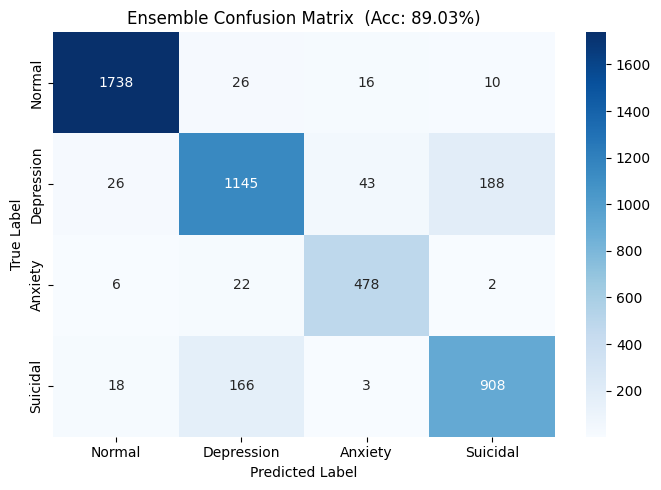

💾 Confusion matrix saved as 'ensemble_confusion_matrix.png'


In [10]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7.5: Ensemble Evaluation — Average Accuracy & Full Report
#--------------------------------------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

LABELS = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

def evaluate_ensemble(model_a, model_b, val_loader_bert, val_loader_rob):
    """
    Runs both models over the validation set in sync,
    fuses their softmax outputs (50/50), and computes:
      - Overall accuracy
      - Per-class accuracy
      - Macro F1
      - Confusion matrix
    """
    model_a.eval()
    model_b.eval()

    all_preds, all_labels = [], []

    # Zip both loaders so we process the same samples together
    loader_pairs = zip(val_loader_bert, val_loader_rob)

    print("⏳ Running ensemble evaluation on validation set...")
    with torch.no_grad():
        for batch_bert, batch_rob in tqdm(loader_pairs, total=len(val_loader_bert)):

            # BERT stream
            ids_a   = batch_bert['input_ids'].to(device)
            mask_a  = batch_bert['attention_mask'].to(device)
            labels  = batch_bert['labels']          # ground truth (same for both)

            prob_a  = F.softmax(model_a(ids_a, mask_a), dim=1)

            # RoBERTa stream
            ids_b   = batch_rob['input_ids'].to(device)
            mask_b  = batch_rob['attention_mask'].to(device)
            prob_b  = F.softmax(model_b(ids_b, mask_b), dim=1)

            # Soft-vote fusion (matches Module 7 / Module 8 logic)
            fused   = (0.5 * prob_a) + (0.5 * prob_b)
            preds   = torch.argmax(fused, dim=1).cpu().tolist()

            all_preds.extend(preds)
            all_labels.extend(labels.tolist())

    # ── 1. Overall Accuracy ──────────────────────────────────────────────
    overall_acc = accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average='macro')

    print("\n" + "═"*55)
    print("       🧠 ENSEMBLE EVALUATION RESULTS")
    print("═"*55)
    print(f"  ✅ Overall Accuracy  : {overall_acc * 100:.2f}%")
    print(f"  ✅ Macro F1 Score    : {macro_f1 * 100:.2f}%")

    # ── 2. Per-class Accuracy ────────────────────────────────────────────
    cm          = confusion_matrix(all_labels, all_preds)
    per_class   = cm.diagonal() / cm.sum(axis=1)

    print("\n  📊 Per-Class Accuracy:")
    for lbl, acc in zip(LABELS, per_class):
        bar = "█" * int(acc * 20)
        print(f"    {lbl:<12} {acc*100:5.1f}%  {bar}")

    # ── 3. Full Classification Report ───────────────────────────────────
    print("\n  📋 Full Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=LABELS))
    print("═"*55)

    # ── 4. Confusion Matrix Plot ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS, ax=ax
    )
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Ensemble Confusion Matrix  (Acc: {overall_acc*100:.2f}%)")
    plt.tight_layout()
    plt.savefig("ensemble_confusion_matrix.png", dpi=150)
    plt.show()
    print("💾 Confusion matrix saved as 'ensemble_confusion_matrix.png'")

    return overall_acc, macro_f1


# ── LOAD SAVED WEIGHTS & RUN ─────────────────────────────────────────────
try:
    eval_bert = WeightedTransformer(config.BERT_NAME, 4, token=token).to(device)
    eval_bert.load_state_dict(torch.load('best_bert.bin', map_location=device))

    eval_rob = WeightedTransformer(config.ROBERTA_NAME, 4, token=token).to(device)
    eval_rob.load_state_dict(torch.load('best_roberta.bin', map_location=device))

    print("✅ Weights loaded. Starting evaluation...\n")
    overall_acc, macro_f1 = evaluate_ensemble(
        eval_bert, eval_rob,
        val_loader_bert, val_loader_rob
    )

except FileNotFoundError as e:
    print(f"❌ Model file not found: {e}")
    print("   → Please complete Module 6 (training) first.")
except NameError as e:
    print(f"❌ Missing variable: {e}")
    print("   → Re-run Modules 1–5 before this cell.")

In [13]:
#-------------------------------------------------------------------------
# MODULE 8: The Unified Ensemble Demo (Post-Restart Version)
#-------------------------------------------------------------------------

import torch, torch.nn as nn, torch.nn.functional as F
import gradio as gr
from transformers import AutoTokenizer, AutoModel

# 1. Re-define the Architecture (The "Blueprint")
class WeightedTransformer(nn.Module):
    def __init__(self, model_name, n_classes, token=None):
        super(WeightedTransformer, self).__init__()
        self.transformer = AutoModel.from_pretrained(model_name, output_hidden_states=True, token=token)
        num_layers = self.transformer.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.ones(num_layers))
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.transformer.config.hidden_size, n_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = torch.stack(outputs.hidden_states)
        alphas = torch.softmax(self.layer_weights, dim=0)
        weighted_output = torch.sum(alphas.view(-1, 1, 1, 1) * hidden_states, dim=0)
        return self.out(self.drop(weighted_output[:, 0, :]))

# 2. Setup Device & Authenticated Token
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Ensure hf_token is available from your Kaggle Secrets
token = hf_token if 'hf_token' in globals() else None

# 3. Load weights from storage (/kaggle/working)
try:
    # Load BERT component
    model_bert = WeightedTransformer("mental/mental-bert-base-uncased", 4, token=token).to(device)
    model_bert.load_state_dict(torch.load('best_bert.bin', map_location=device))
    
    # Load RoBERTa component
    model_rob = WeightedTransformer("distilroberta-base", 4).to(device)
    model_rob.load_state_dict(torch.load('best_roberta.bin', map_location=device))
    
    model_bert.eval(); model_rob.eval()
    print("🚀 Ensemble System Online: Weights loaded successfully.")
except Exception as e:
    print(f"❌ Error: Could not find .bin files. Did you finish Module 6 training? Details: {e}")

# 4. Tokenizers
tokenizer_bert = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased", token=token)
tokenizer_rob = AutoTokenizer.from_pretrained("distilroberta-base")

# 5. Prediction Logic
def predict_ensemble(text):
    with torch.no_grad():
        # BERT Stream
        enc_a = tokenizer_bert(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_a = F.softmax(model_bert(enc_a['input_ids'], enc_a['attention_mask']), dim=1)
        
        # RoBERTa Stream
        enc_b = tokenizer_rob(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_b = F.softmax(model_rob(enc_b['input_ids'], enc_b['attention_mask']), dim=1)
        
        # Nuclear Fusion (Soft-Voting)
        final_probs = (0.5 * prob_a) + (0.5 * prob_b)
        final_probs = final_probs.flatten()
        
        labels = ['Normal', 'Depression', 'Anxiety', 'Suicidal']
        return {labels[i]: float(final_probs[i]) for i in range(len(labels))}

# 6. Launch
demo = gr.Interface(
    fn=predict_ensemble,
    inputs=gr.Textbox(lines=4, label="User Input"),
    outputs=gr.Label(num_top_classes=4, label="Ensemble Confidence"),
    title="🧠 Weighted Ensemble Mental Health Detector",
    theme="soft"
)
demo.launch(share=True)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

❌ Error: Could not find .bin files. Did you finish Module 6 training? Details: Error(s) in loading state_dict for WeightedTransformer:
	Missing key(s) in state_dict: "out.weight", "out.bias". 
	Unexpected key(s) in state_dict: "norm.weight", "norm.bias", "classifier.0.weight", "classifier.0.bias", "classifier.3.weight", "classifier.3.bias". 


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://aa3789a1c3f6c34278.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


In [12]:
# Run this to confirm data integrity
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"Number of overlapping samples: {len(overlap)}")

Number of overlapping samples: 0
